# Reduced-Form ECL: Step-by-Step Walkthrough

This notebook traces the full calculation chain — from physical damage estimate to
IFRS 9 Expected Credit Loss — for **one concrete vendor realisation**.
The goal is transparency: every intermediate quantity is shown so you can see
exactly what drives the result.

**Key idea.** A vendor is modelled as one independent draw per property from
that property's triangular uncertainty distribution (calibrated to the
CFRF/GARP observed min/mean/max). Changing `VENDOR_SEED` gives you a
different vendor; keeping `PORTFOLIO_SEED` fixed holds the loan book constant
so results are directly comparable across vendors.

**Calculation chain:**
```
CFRF/GARP data → triangular distribution per property
               → sample one vendor (one d per property)
               → loan portfolio (EAD, baseline PD, LGD, maturity)
               → transmission:  PD_12m(d) = PD_0 × exp(α × d)
                                LGD(d)    = LGD_0 + λ × d
               → lifetime PDs:  PD_LT = 1 − (1 − PD_12m)^T
               → SICR staging:  PD_LT_stressed / PD_LT_base > τ  →  Stage 2
               → ECL:           Stage 1 = PD_12m × LGD × EAD
                                Stage 2 = PD_LT  × LGD × EAD
```

In [118]:
# =============================================================================
# PARAMETERS — edit this cell to explore how results change
# =============================================================================

# --- Vendor selection ---
VENDOR_SEED    = 13     # integer ≥ 0 — change to 'consult a different vendor'
PORTFOLIO_SEED = 42   # controls loan characteristics — keep fixed to compare vendors

# --- Flood hazard ---
RETURN_PERIOD = 20    # years — the CFRF/GARP data is for this event
# Annual exceedance probability = 1 / RETURN_PERIOD = 0.5%
# This enters the UNCONDITIONAL framing only (see Step 5).

# --- Probability framing ---
# "conditional"   — assumes the flood definitely occurs (p = 1.0)
#                   isolates vendor disagreement; natural for stress testing
# "unconditional" — weights stressed PD by the probability the flood occurs
#                   gives the expected ECL uplift; more natural for provisioning
# The notebook computes BOTH and compares them in the summary.

# --- Reduced-form transmission ---
ALPHA      = 2.0   # PD amplification:  PD_12m(d) = PD_0 × exp(α × d)
                   #   higher α → sharper PD response to damage
LAMBDA_LGD = 0.25  # LGD sensitivity:   LGD(d) = LGD_0 + λ × d
                   #   higher λ → losses worsen faster with damage

# --- IFRS 9 staging ---
TAU = 2.0          # SICR threshold: stage if PD_LT_stressed / PD_LT_base > τ
                   #   EBA benchmark = 2.0 (lifetime PD doubles)

# --- Loan portfolio draws ---
EAD_LOW,  EAD_HIGH  = 0.5,  5.0   # EAD £m, Uniform
PD_MU,    PD_SIGMA  = -5.5, 0.8   # baseline PD_12m log-normal (median ≈ 0.4%)
LGD_LOW,  LGD_HIGH  = 0.20, 0.45  # baseline LGD, Uniform
MAT_LOW,  MAT_HIGH  = 5,    25    # loan maturity years, discrete Uniform

# --- Data ---
DATA_PATH = '../../data/raw/cfrf_garp_defended_flood.csv'

In [119]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

BLUE, RED, GREY, AMBER = '#4878CF', '#E84D0E', '#888888', '#F0A500'

---
## Step 1 — Physical Risk Data

Load the CFRF/GARP benchmarking data (100 UK properties, 13 vendors,
1-in-200 year defended combined flood, 2030).
For each property we fit a **triangular distribution** to the observed
vendor spread:
- Support: `[min_dr, max_dr]`
- Mode: `3 × mean_dr − min_dr − max_dr`, clamped to the support

This distribution represents our model of the space of possible vendor
damage estimates for each property.

In [120]:
df = pd.read_csv(DATA_PATH)
df.rename(columns={'minimim_dr': 'minimum_dr'}, inplace=True)
df = df.dropna(subset=['property_rank']).reset_index(drop=True)
df['property_rank'] = df['property_rank'].astype(int)
n = len(df)

# Triangular distribution parameters
tri_a = df['minimum_dr'].values.astype(float)
tri_b = df['maximum_dr'].values.astype(float)
tri_c = np.clip(3.0 * df['mean_dr'].values - tri_a - tri_b, tri_a, tri_b)

print(f'Properties: {n}')
print(f'  Zero-damage (min=mean=max=0): {(tri_b == 0).sum()}')
print(f'  Point mass (min == max > 0):  {((tri_b == tri_a) & (tri_b > 0)).sum()}')
print(f'  Full triangular uncertainty:  {(tri_b > tri_a).sum()}')

# Working DataFrame — will accumulate columns step by step
results = pd.DataFrame({
    'property_rank': df['property_rank'],
    'd_min':  tri_a,
    'd_mean': df['mean_dr'].values,
    'd_max':  tri_b,
    'd_mode': tri_c,
})

Properties: 100
  Zero-damage (min=mean=max=0): 20
  Point mass (min == max > 0):  0
  Full triangular uncertainty:  80


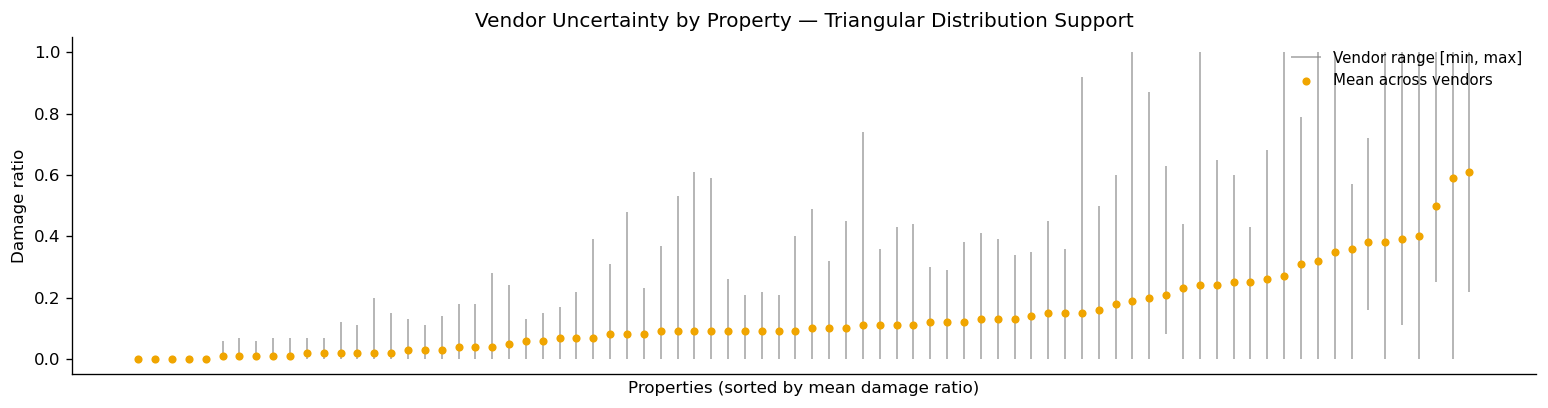

Across 80 non-zero properties:
  Mean vendor spread (max − min): 0.412
  Properties where spread > 0.5:  25


In [121]:
# Show the triangular uncertainty for each property
# Properties are sorted by mean damage ratio; zero-damage excluded for clarity
mask = tri_b > 0
idx  = np.argsort(df['mean_dr'].values[mask])

a_plot = tri_a[mask][idx]
b_plot = tri_b[mask][idx]
c_plot = df['mean_dr'].values[mask][idx]
x_pos  = np.arange(mask.sum())

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.vlines(x_pos, a_plot, b_plot, color=GREY, linewidth=1.2, alpha=0.6,
          label='Vendor range [min, max]')
ax.scatter(x_pos, c_plot, color=AMBER, s=15, zorder=3, label='Mean across vendors')

ax.set_xlabel('Properties (sorted by mean damage ratio)')
ax.set_ylabel('Damage ratio')
ax.set_title('Vendor Uncertainty by Property — Triangular Distribution Support')
ax.set_xticks([])
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

print(f'Across {mask.sum()} non-zero properties:')
print(f'  Mean vendor spread (max − min): {(b_plot - a_plot).mean():.3f}')
print(f'  Properties where spread > 0.5:  {(b_plot - a_plot > 0.5).sum()}')

---
## Step 2 — Sample One Vendor

Draw one damage estimate per property from its triangular distribution.
This represents the full portfolio assessment produced by a single vendor.

Change `VENDOR_SEED` in the parameters cell to consult a different vendor.

In [122]:
def triangular_sample(rng, a, b, c):
    """Draw one sample per property from Triangular(a, c, b) using inverse CDF."""
    u    = rng.uniform(size=len(a))
    span = np.where(b > a, b - a, 1.0)
    fc   = np.where(b > a, (c - a) / span, 0.0)
    left  = a + np.sqrt(np.maximum(u, 0) * span * np.maximum(c - a, 0))
    right = b - np.sqrt(np.maximum(1 - u, 0) * span * np.maximum(b - c, 0))
    x     = np.where(u <= fc, left, right)
    return np.where(b > a, np.clip(x, 0, 1), a)   # point mass → return a

vendor_rng = np.random.default_rng(VENDOR_SEED)
d_vendor   = triangular_sample(vendor_rng, tri_a, tri_b, tri_c)

results['d_vendor'] = d_vendor

# How does this vendor compare to the observed spread?
non_zero = tri_b > 0
d_rel = np.where(
    non_zero,
    (d_vendor - tri_a) / np.where(non_zero, tri_b - tri_a, 1.0),
    np.nan
)
print(f'Vendor (seed={VENDOR_SEED}) damage estimates:')
print(f'  Non-zero properties reporting damage: {(d_vendor > 0).sum()}')
print(f'  Damage ratio — mean: {d_vendor.mean():.3f},  max: {d_vendor.max():.3f}')
print(f'  Position within vendor range (0=min, 1=max):')
print(f'    Median: {np.nanmedian(d_rel):.2f},  Mean: {np.nanmean(d_rel):.2f}')
print(f'    (0.5 = sits at the midpoint of the vendor spread)')

Vendor (seed=13) damage estimates:
  Non-zero properties reporting damage: 80
  Damage ratio — mean: 0.135,  max: 0.890
  Position within vendor range (0=min, 1=max):
    Median: 0.33,  Mean: 0.39
    (0.5 = sits at the midpoint of the vendor spread)


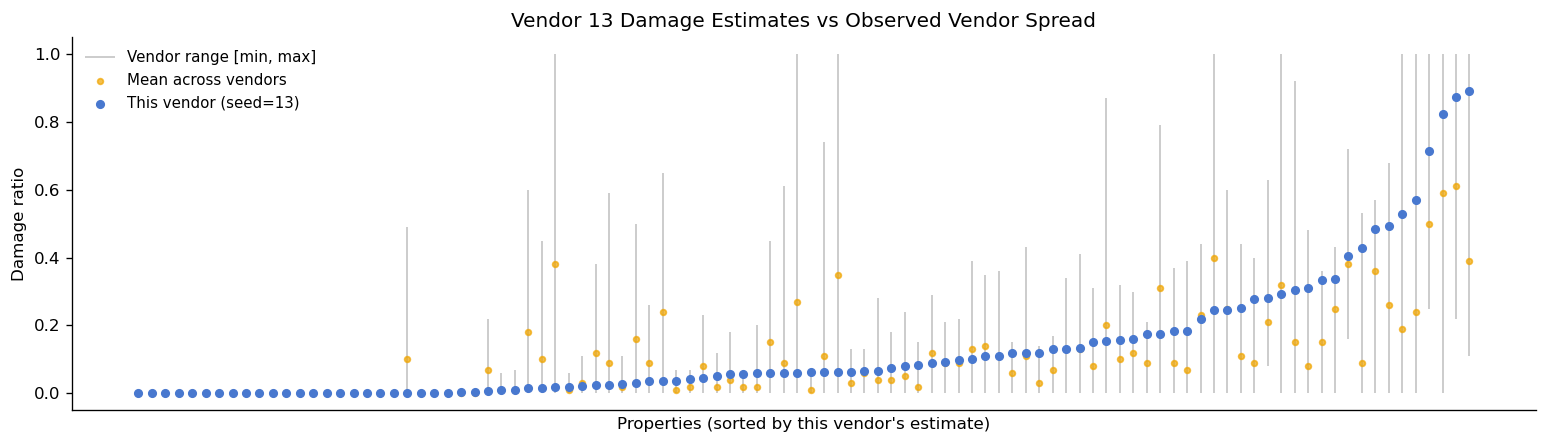

In [123]:
# Plot: this vendor's estimates vs the observed spread, sorted by d_vendor
order = np.argsort(d_vendor)
x_pos = np.arange(n)

fig, ax = plt.subplots(figsize=(13, 3.8))
ax.vlines(x_pos, tri_a[order], tri_b[order],
          color=GREY, linewidth=1.0, alpha=0.5, label='Vendor range [min, max]')
ax.scatter(x_pos, df['mean_dr'].values[order],
           color=AMBER, s=12, zorder=2, alpha=0.7, label='Mean across vendors')
ax.scatter(x_pos, d_vendor[order],
           color=BLUE, s=20, zorder=3, label=f'This vendor (seed={VENDOR_SEED})')

ax.set_xlabel('Properties (sorted by this vendor\'s estimate)')
ax.set_ylabel('Damage ratio')
ax.set_title(f'Vendor {VENDOR_SEED} Damage Estimates vs Observed Vendor Spread')
ax.set_xticks([])
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

---
## Step 3 — Loan Portfolio

Construct the stylised loan book: one loan per CFRF/GARP property.
Each loan's financial characteristics (EAD, baseline PD, LGD, maturity)
are drawn independently from assumed distributions.

These are **baseline** (pre-flood) credit metrics — before any damage is applied.

In [124]:
port_rng = np.random.default_rng(PORTFOLIO_SEED)

ead_m       = port_rng.uniform(EAD_LOW, EAD_HIGH, size=n)
pd_12m_base = np.clip(
    stats.lognorm.rvs(s=PD_SIGMA, scale=np.exp(PD_MU), size=n,
                      random_state=int(port_rng.integers(2**31))),
    1e-6, 0.9999
)
lgd_base    = port_rng.uniform(LGD_LOW, LGD_HIGH, size=n)
maturity    = port_rng.integers(MAT_LOW, MAT_HIGH + 1, size=n)
pd_lt_base  = 1.0 - (1.0 - pd_12m_base) ** maturity
ecl_base    = pd_12m_base * lgd_base * ead_m

results['ead_m']       = ead_m
results['pd_12m_base'] = pd_12m_base
results['lgd_base']    = lgd_base
results['maturity']    = maturity
results['pd_lt_base']  = pd_lt_base
results['ecl_base']    = ecl_base

print('Loan portfolio (baseline, pre-flood):')
print(f'  Total EAD:          £{ead_m.sum():.1f}m')
print(f'  Baseline ECL:       £{ecl_base.sum():.4f}m   ({ecl_base.sum()/ead_m.sum()*1e4:.1f} bps)')
print(f'  PD_12m (mean):      {pd_12m_base.mean()*100:.3f}%')
print(f'  LGD (mean):         {lgd_base.mean()*100:.1f}%')
print(f'  Maturity (mean):    {maturity.mean():.1f}y')
print()
print('First 5 loans:')
display_cols = ['property_rank', 'd_vendor', 'ead_m', 'pd_12m_base', 'lgd_base', 'maturity']
print(results[display_cols].head().to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Loan portfolio (baseline, pre-flood):
  Total EAD:          £269.0m
  Baseline ECL:       £0.4653m   (17.3 bps)
  PD_12m (mean):      0.549%
  LGD (mean):         32.5%
  Maturity (mean):    15.1y

First 5 loans:
 property_rank  d_vendor  ead_m  pd_12m_base  lgd_base  maturity
             1    0.8237 3.9828       0.0030    0.3749        24
             2    0.7147 2.4750       0.0033    0.2665        11
             3    0.4856 4.3637       0.0014    0.4423        25
             4    0.1742 3.6382       0.0022    0.3947        15
             5    0.0637 0.9238       0.0015    0.3792        15


---
## Step 4 — Damage Transmission

Apply the reduced-form transmission model to convert damage ratios into
stressed credit metrics:

$$
\text{PD}_{12m}(d) = \text{PD}_0 \cdot e^{\alpha d}
\qquad
\text{LGD}(d) = \min(\text{LGD}_0 + \lambda d,\; 1)
$$

- $\alpha$ controls how sharply PD escalates with damage — a doubling of default risk per unit of damage. Higher $\alpha$ → more sensitive.
- $\lambda$ shifts LGD linearly — collateral recovery worsens as the property is damaged.

In [125]:
pd_12m_str = np.clip(pd_12m_base * np.exp(ALPHA * d_vendor), 0, 0.9999)
lgd_str    = np.minimum(lgd_base + LAMBDA_LGD * d_vendor, 1.0)
pd_lt_str  = 1.0 - (1.0 - pd_12m_str) ** maturity

results['pd_12m_str'] = pd_12m_str
results['lgd_str']    = lgd_str
results['pd_lt_str']  = pd_lt_str

# PD multiplier and LGD uplift
pd_mult   = pd_12m_str / pd_12m_base
lgd_uplift = lgd_str - lgd_base

changed = d_vendor > 0
print(f'Transmission results (loans with d > 0: {changed.sum()} of {n}):')
print(f'  PD_12m multiplier  — mean: {pd_mult[changed].mean():.2f}x,  '
      f'max: {pd_mult[changed].max():.2f}x')
print(f'  LGD uplift         — mean: {lgd_uplift[changed].mean():.3f},  '
      f'max: {lgd_uplift[changed].max():.3f}')

Transmission results (loans with d > 0: 80 of 100):
  PD_12m multiplier  — mean: 1.56x,  max: 5.93x
  LGD uplift         — mean: 0.042,  max: 0.223


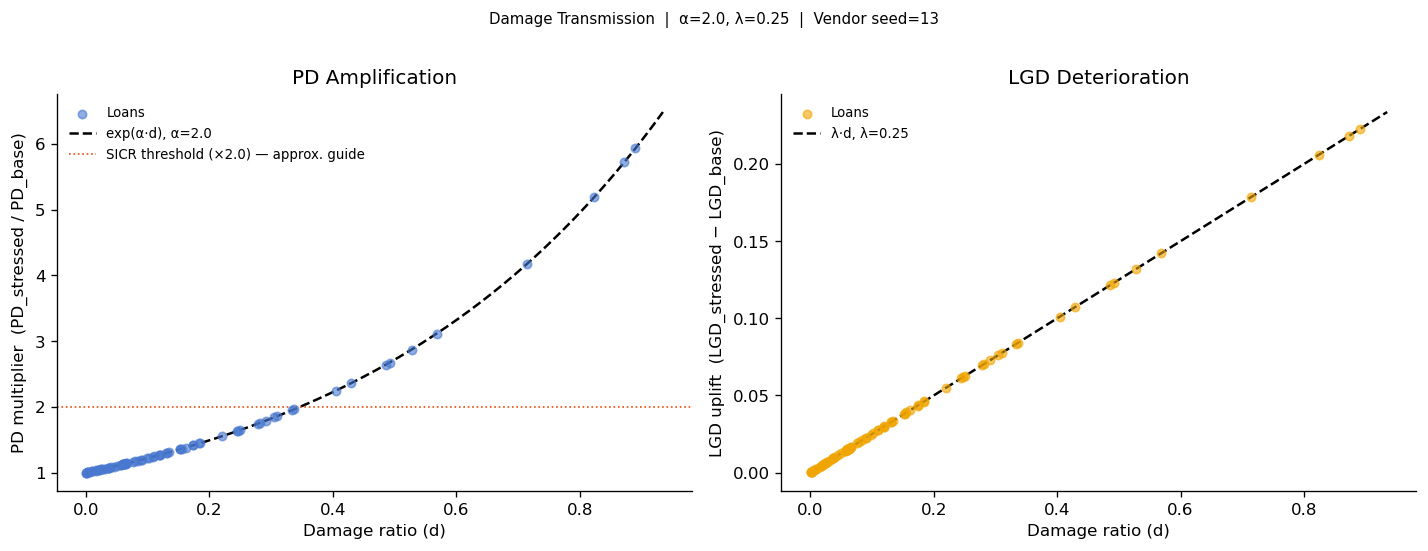

In [126]:
# Two-panel: damage → stressed PD (as multiplier), damage → LGD uplift
# Overlay the theoretical curves to show the functional form
d_curve = np.linspace(0, results['d_vendor'].max() * 1.05, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: PD multiplier
ax = axes[0]
ax.scatter(d_vendor[changed], pd_mult[changed],
           color=BLUE, s=25, alpha=0.6, zorder=3, label='Loans')
ax.plot(d_curve, np.exp(ALPHA * d_curve),
        color='black', linewidth=1.5, linestyle='--',
        label=f'exp(α·d), α={ALPHA}')
ax.axhline(TAU, color=RED, linewidth=1.0, linestyle=':',
           label=f'SICR threshold (×{TAU}) — approx. guide')
ax.set_xlabel('Damage ratio (d)')
ax.set_ylabel('PD multiplier  (PD_stressed / PD_base)')
ax.set_title('PD Amplification')
ax.legend(frameon=False, fontsize=8)

# Right: LGD uplift
ax2 = axes[1]
ax2.scatter(d_vendor[changed], lgd_uplift[changed],
            color=AMBER, s=25, alpha=0.6, zorder=3, label='Loans')
ax2.plot(d_curve, LAMBDA_LGD * d_curve,
         color='black', linewidth=1.5, linestyle='--',
         label=f'λ·d, λ={LAMBDA_LGD}')
ax2.set_xlabel('Damage ratio (d)')
ax2.set_ylabel('LGD uplift  (LGD_stressed − LGD_base)')
ax2.set_title('LGD Deterioration')
ax2.legend(frameon=False, fontsize=8)

fig.suptitle(f'Damage Transmission  |  α={ALPHA}, λ={LAMBDA_LGD}  |  '
             f'Vendor seed={VENDOR_SEED}', fontsize=9, y=1.01)
plt.tight_layout()
plt.show()

---
## Step 5 — IFRS 9 Staging (SICR Test)

A loan is moved to **Stage 2** (lifetime ECL) if there has been a Significant
Increase in Credit Risk (SICR) since origination. We proxy this with the EBA
benchmark: stage if the **lifetime PD has more than doubled**:

$$
\text{SICR ratio} = \frac{\text{PD}_{LT,\text{adj}}}{\text{PD}_{LT,\text{base}}} > \tau
$$

### Two probability framings

The damage ratios come from a **1-in-200 year event** (p = 0.5%/year). How we
treat that probability fundamentally changes the calculation:

**Conditional** — the flood is treated as certain (p = 1). Stressed PDs enter
directly. This answers: *"If this flood occurs, how does our ECL change?"*
Useful for stress testing; also isolates vendor disagreement most clearly.

$$
\text{PD}_{LT,\text{adj}} = \text{PD}_{LT,\text{stressed}} \qquad (p=1)
$$

**Unconditional** — PDs are probability-weighted mixtures of the flood and
no-flood outcomes. This answers: *"What is our expected ECL, accounting for
the probability that this flood happens?"*

$$
p_{LT} = 1 - (1 - p_{\text{annual}})^T
$$
$$
\text{PD}_{LT,\text{adj}} = (1 - p_{LT}) \cdot \text{PD}_{LT,\text{base}}
                           + p_{LT} \cdot \text{PD}_{LT,\text{stressed}}
$$

With $p_{\text{annual}} = 0.005$ and $T = 15$ years: $p_{LT} \approx 7.2\%$ —
so even under the unconditional framing the stressed PD gets meaningful weight
over the loan lifetime, but the annual (12-month) effect is very small.

In [127]:
p_annual  = 1.0 / RETURN_PERIOD                        # 0.005 for RP200
p_lifetime = 1.0 - (1.0 - p_annual) ** maturity        # per-loan lifetime flood prob

# ── Conditional framing (p = 1): flood is certain ────────────────────────────
sicr_cond  = pd_lt_str / pd_lt_base
stage_cond = np.where(sicr_cond > TAU, 2, 1)

# ── Unconditional framing: probability-weighted PDs ──────────────────────────
# 12-month: mixture over the coming year
pd_12m_uncond = (1.0 - p_annual)  * pd_12m_base + p_annual  * pd_12m_str
# Lifetime:  mixture over loan maturity
pd_lt_uncond  = (1.0 - p_lifetime) * pd_lt_base  + p_lifetime * pd_lt_str

sicr_uncond  = pd_lt_uncond / pd_lt_base
stage_uncond = np.where(sicr_uncond > TAU, 2, 1)

# Store both in results
results['p_lifetime']    = p_lifetime
results['sicr_cond']     = sicr_cond
results['stage_cond']    = stage_cond
results['sicr_uncond']   = sicr_uncond
results['stage_uncond']  = stage_uncond
results['pd_12m_uncond'] = pd_12m_uncond
results['pd_lt_uncond']  = pd_lt_uncond

n_s2_cond   = (stage_cond   == 2).sum()
n_s2_uncond = (stage_uncond == 2).sum()

print(f'Flood hazard: 1-in-{RETURN_PERIOD}yr  |  '
      f'p_annual = {p_annual:.4f}  |  '
      f'p_lifetime (mean over portfolio) = {p_lifetime.mean():.4f}')
print()
print(f'SICR staging results (τ = {TAU}):')
print(f'  {"":30s}  {"Stage 1":>8}  {"Stage 2":>8}')
print(f'  {"Conditional   (flood certain)":30s}  {n - n_s2_cond:>8}  {n_s2_cond:>8}')
print(f'  {"Unconditional (p = 1/RP)":30s}  {n - n_s2_uncond:>8}  {n_s2_uncond:>8}')
print()
if n_s2_uncond > 0:
    print('Loans in Stage 2 under unconditional framing:')
    s2u = results[stage_uncond == 2][
        ['property_rank', 'd_vendor', 'p_lifetime', 'sicr_uncond', 'pd_lt_base', 'pd_lt_uncond']
    ].copy()
    print(s2u.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
else:
    print('No loans reach Stage 2 under the unconditional framing.')

Flood hazard: 1-in-20yr  |  p_annual = 0.0500  |  p_lifetime (mean over portfolio) = 0.5133

SICR staging results (τ = 2.0):
                                   Stage 1   Stage 2
  Conditional   (flood certain)         90        10
  Unconditional (p = 1/RP)              94         6

Loans in Stage 2 under unconditional framing:
 property_rank  d_vendor  p_lifetime  sicr_uncond  pd_lt_base  pd_lt_uncond
             1    0.8237      0.7080       3.4898      0.0692        0.2414
             2    0.7147      0.4312       2.2792      0.0354        0.0807
             3    0.4856      0.7226       2.1349      0.0340        0.0726
             6    0.8724      0.5123       3.2057      0.0346        0.1108
            10    0.8903      0.3366       2.5526      0.0256        0.0653
            22    0.5274      0.6594       2.0883      0.0881        0.1841


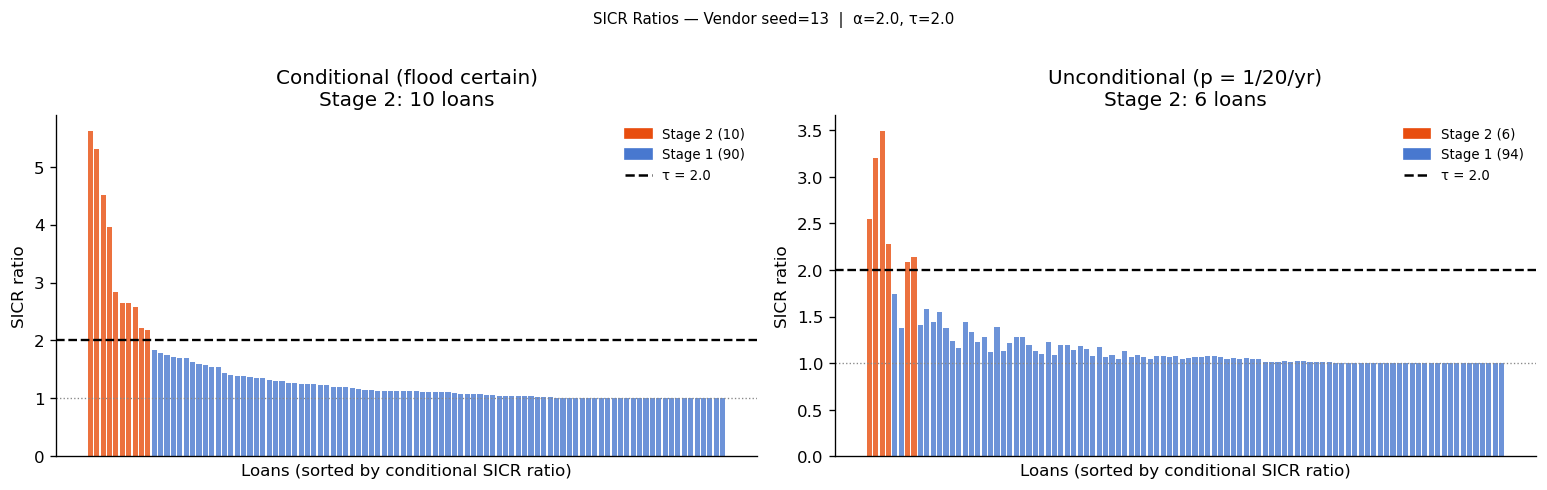

In [128]:
# SICR ratios side by side: conditional vs unconditional
order = np.argsort(sicr_cond)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, sicr, stage, title, framing_label in [
    (axes[0], sicr_cond,   stage_cond,   'Conditional (flood certain)',    f'p = 1'),
    (axes[1], sicr_uncond, stage_uncond, f'Unconditional (p = 1/{RETURN_PERIOD}/yr)', f'p = {p_annual}'),
]:
    colors = [RED if s == 2 else BLUE for s in stage[order]]
    ax.bar(np.arange(n), sicr[order], color=colors, width=0.8, alpha=0.8)
    ax.axhline(TAU, color='black', linewidth=1.4, linestyle='--',
               label=f'τ = {TAU}')
    ax.axhline(1.0, color=GREY, linewidth=0.8, linestyle=':')
    n_s2 = (stage == 2).sum()
    ax.set_xlabel('Loans (sorted by conditional SICR ratio)')
    ax.set_ylabel('SICR ratio')
    ax.set_title(f'{title}\nStage 2: {n_s2} loans')
    ax.set_xticks([])
    legend_handles = [
        mpatches.Patch(color=RED,  label=f'Stage 2 ({n_s2})'),
        mpatches.Patch(color=BLUE, label=f'Stage 1 ({n - n_s2})'),
        plt.Line2D([0],[0], color='black', linestyle='--', label=f'τ = {TAU}'),
    ]
    ax.legend(handles=legend_handles, frameon=False, fontsize=8)

fig.suptitle(f'SICR Ratios — Vendor seed={VENDOR_SEED}  |  α={ALPHA}, τ={TAU}',
             fontsize=9, y=1.01)
plt.tight_layout()
plt.show()

# Note: unconditional SICR ratios are compressed toward 1 because the stressed
# PD is diluted by (1 - p_lifetime) ≈ 93% weight on the baseline PD.

---
## Step 6 — ECL Calculation

Expected Credit Loss is computed per loan based on its stage:

| Stage | ECL formula | Rationale |
|---|---|---|
| Stage 1 | $\text{PD}_{12m} \times \text{LGD} \times \text{EAD}$ | 12-month horizon; no SICR triggered |
| Stage 2 | $\text{PD}_{LT} \times \text{LGD} \times \text{EAD}$ | Lifetime horizon; SICR triggered |

In both cases we use the **stressed** PD and LGD from Step 4.

In [129]:
def compute_ecl(pd_12m, pd_lt, lgd, ead, stage):
    """ECL = PD_12m × LGD × EAD (Stage 1) or PD_LT × LGD × EAD (Stage 2)."""
    return np.where(stage == 2, pd_lt * lgd * ead, pd_12m * lgd * ead)

# Conditional ECL (stressed PDs, stage from conditional SICR)
ecl_cond = compute_ecl(pd_12m_str, pd_lt_str, lgd_str, ead_m, stage_cond)

# Unconditional ECL (probability-adjusted PDs, stage from unconditional SICR)
ecl_uncond = compute_ecl(pd_12m_uncond, pd_lt_uncond, lgd_str, ead_m, stage_uncond)
# Note: LGD_stressed used in both cases — if default occurs after a flood,
# collateral recovery is impaired regardless of probability framing.

results['ecl_cond']   = ecl_cond
results['ecl_uncond'] = ecl_uncond

ead_tot = ead_m.sum()
for label, ecl, stage in [
    ('Conditional',   ecl_cond,   stage_cond),
    ('Unconditional', ecl_uncond, stage_uncond),
]:
    ecl_s1 = ecl[stage == 1].sum()
    ecl_s2 = ecl[stage == 2].sum()
    print(f'{label} framing:')
    print(f'  Total stressed ECL:  £{ecl.sum():.5f}m   ({ecl.sum()/ead_tot*1e4:.2f} bps)')
    print(f'  Stage 1 ECL:         £{ecl_s1:.5f}m')
    print(f'  Stage 2 ECL:         £{ecl_s2:.5f}m')
    print(f'  Uplift vs baseline:  {(ecl.sum()/ecl_base.sum()-1)*100:+.1f}%')
    print()

Conditional framing:
  Total stressed ECL:  £3.35957m   (124.88 bps)
  Stage 1 ECL:         £0.58039m
  Stage 2 ECL:         £2.77917m
  Uplift vs baseline:  +622.0%

Unconditional framing:
  Total stressed ECL:  £1.83821m   (68.33 bps)
  Stage 1 ECL:         £0.50021m
  Stage 2 ECL:         £1.33800m
  Uplift vs baseline:  +295.1%



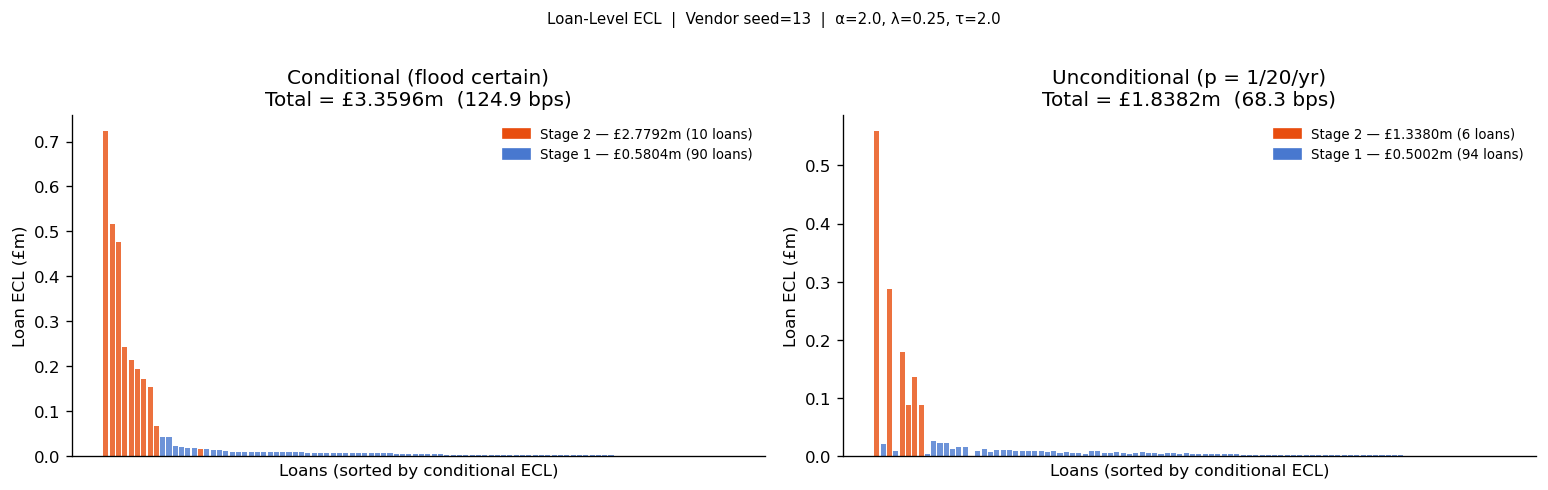

In [130]:
# Loan-level ECL under both framings, sorted by conditional ECL
order = np.argsort(ecl_cond)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, ecl, stage, title in [
    (axes[0], ecl_cond,   stage_cond,   'Conditional (flood certain)'),
    (axes[1], ecl_uncond, stage_uncond, f'Unconditional (p = 1/{RETURN_PERIOD}/yr)'),
]:
    colors = [RED if s == 2 else BLUE for s in stage[order]]
    ax.bar(np.arange(n), ecl[order], color=colors, width=0.8, alpha=0.8)
    ecl_s1 = ecl[stage == 1].sum()
    ecl_s2 = ecl[stage == 2].sum()
    n_s2   = (stage == 2).sum()
    ax.set_xlabel('Loans (sorted by conditional ECL)')
    ax.set_ylabel('Loan ECL (£m)')
    ax.set_title(f'{title}\nTotal = £{ecl.sum():.4f}m  ({ecl.sum()/ead_m.sum()*1e4:.1f} bps)')
    ax.set_xticks([])
    legend_handles = [
        mpatches.Patch(color=RED,  label=f'Stage 2 — £{ecl_s2:.4f}m ({n_s2} loans)'),
        mpatches.Patch(color=BLUE, label=f'Stage 1 — £{ecl_s1:.4f}m ({n - n_s2} loans)'),
    ]
    ax.legend(handles=legend_handles, frameon=False, fontsize=8)

fig.suptitle(f'Loan-Level ECL  |  Vendor seed={VENDOR_SEED}  |  α={ALPHA}, λ={LAMBDA_LGD}, τ={TAU}',
             fontsize=9, y=1.01)
plt.tight_layout()
plt.show()

---
## Step 7 — Summary

Full loan-level results table and a compact comparison across the key stages
of the calculation chain.

In [131]:
print(f'Parameters:  α={ALPHA}  λ={LAMBDA_LGD}  τ={TAU}  '
      f'RP={RETURN_PERIOD}yr (p={p_annual})  vendor seed={VENDOR_SEED}')
print()

rows = [
    {'Framing': 'Baseline (no flood)',
     'ECL (£m)': ecl_base.sum(), 'bps': ecl_base.sum()/ead_tot*1e4,
     'Stage 2 loans': 0, 'Stage 2 ECL (£m)': 0.0},
]
for label, ecl, stage in [
    ('Conditional   (p = 1)',          ecl_cond,   stage_cond),
    (f'Unconditional (p = 1/{RETURN_PERIOD})', ecl_uncond, stage_uncond),
]:
    rows.append({
        'Framing': label,
        'ECL (£m)': ecl.sum(),
        'bps': ecl.sum()/ead_tot*1e4,
        'Stage 2 loans': int((stage==2).sum()),
        'Stage 2 ECL (£m)': ecl[stage==2].sum(),
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print()

# Ratio of conditional to unconditional ECL uplift — shows the probability discount
ecl_uplift_cond   = ecl_cond.sum()   - ecl_base.sum()
ecl_uplift_uncond = ecl_uncond.sum() - ecl_base.sum()
print(f'Conditional ECL uplift:    £{ecl_uplift_cond:.4f}m')
print(f'Unconditional ECL uplift:  £{ecl_uplift_uncond:.4f}m')
print(f'Probability discount:      {ecl_uplift_uncond/ecl_uplift_cond*100:.1f}% of conditional'
      f'  (approx. mean p_LT = {p_lifetime.mean():.3f})')

Parameters:  α=2.0  λ=0.25  τ=2.0  RP=20yr (p=0.05)  vendor seed=13

                 Framing  ECL (£m)      bps  Stage 2 loans  Stage 2 ECL (£m)
     Baseline (no flood)    0.4653  17.2957              0            0.0000
   Conditional   (p = 1)    3.3596 124.8801             10            2.7792
Unconditional (p = 1/20)    1.8382  68.3291              6            1.3380

Conditional ECL uplift:    £2.8943m
Unconditional ECL uplift:  £1.3729m
Probability discount:      47.4% of conditional  (approx. mean p_LT = 0.513)
